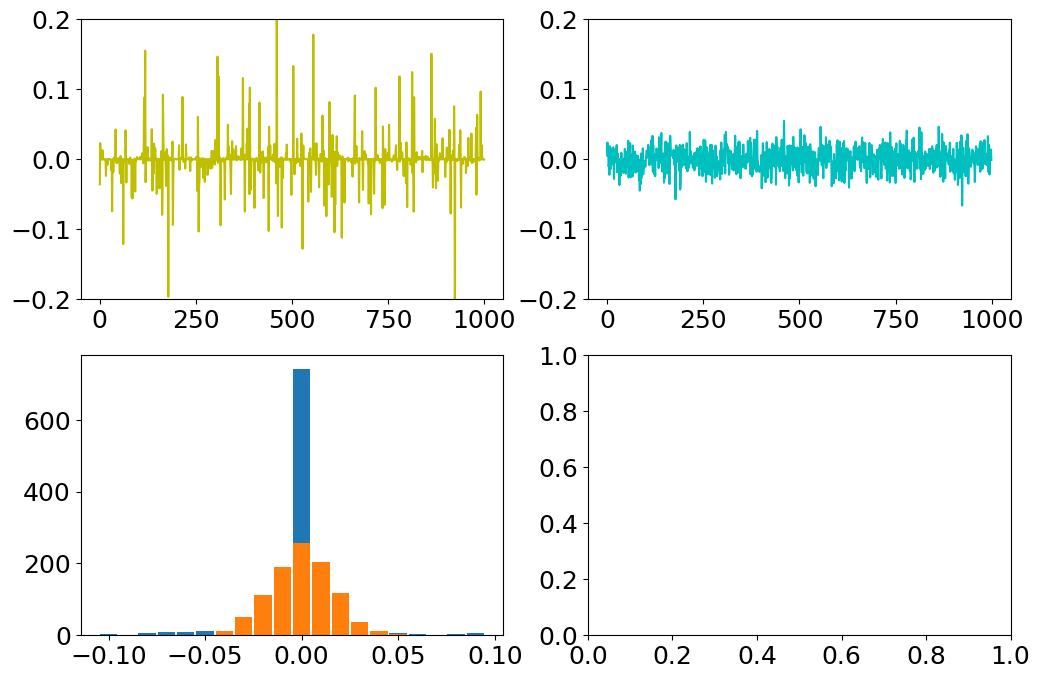

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams.update({'font.size': 18})

# Solve y = Theta * s for "s"
n = 1000 # dimension of s
p = 200 # number of measurements, dim(y)
Theta = np.random.randn(p, n)
y = np.random.randn(p)

# L1 Minimum norm solution s_L1
def L1_norm(x):
    return np.linalg.norm(x, ord=1)

constr = ({'type': 'eq', 'fun': lambda x: Theta @ x - y})
x0 = np.linalg.pinv(Theta) @ y # initialize with L2 solution
res = minimize(L1_norm, x0, method='SLSQP', constraints=constr)
s_L1 = res.x

# L2 Minimum norm solution s_L2
s_L2 = np.linalg.pinv(Theta) @ y

fig, axs = plt.subplots(2, 2)
axs = axs.reshape(-1)
axs[0].plot(s_L1, color='y', linewidth=1.5)  # Fixed 'LineWidth' to 'linewidth'
axs[0].set_ylim(-0.2, 0.2)
axs[1].plot(s_L2, color='c', linewidth=1.5)  # Fixed 'LineWidth' to 'linewidth'
axs[1].set_ylim(-0.2, 0.2)
axs[2].hist(s_L1, bins=np.arange(-0.105, 0.105, 0.01), rwidth=0.9)
axs[2].hist(s_L2, bins=np.arange(-0.105, 0.105, 0.01), rwidth=0.9)

plt.show()